# Introduction: shadow model demo

The pipeline's headline metric is the **modeled shadow fraction**: canopy height + sun position -> shadow footprint at any date/time. This notebook demonstrates the shadow caster on a synthetic canopy, no downloads needed.

For the full pipeline run `pixi run shaduw run --config configs/nl-prototype.toml`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from shaduw_langs_de_snelweg.shadow import cast_shadow_mask

In [2]:
# Synthetic 1 m canopy: a row of 12 m trees south of a bare parking
chm = np.zeros((80, 80), dtype="float32")
chm[50:56, 20:60] = 12.0

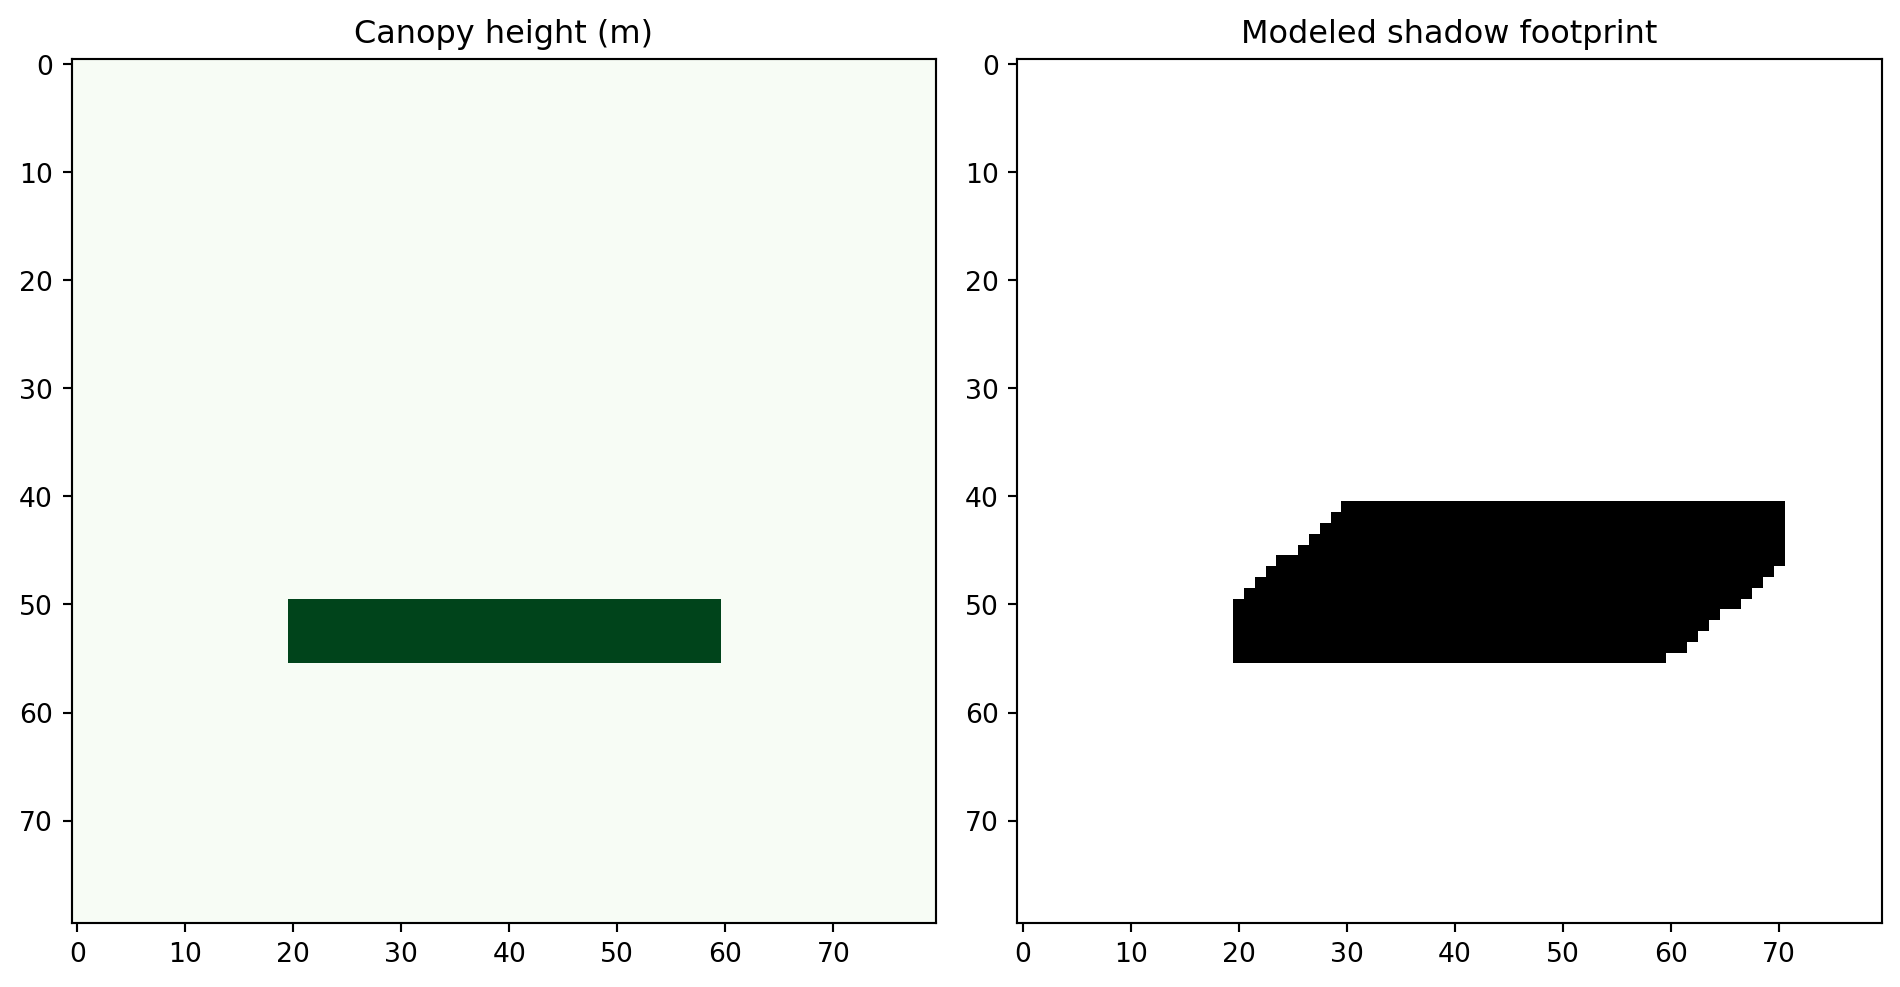

In [3]:
# Summer afternoon: sun in the southwest, 40 degrees up
shadow = cast_shadow_mask(chm, resolution=1.0, azimuth_deg=230.0, elevation_deg=40.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(chm, cmap="Greens")
axes[0].set_title("Canopy height (m)")
axes[1].imshow(shadow, cmap="gray_r")
axes[1].set_title("Modeled shadow footprint")
plt.tight_layout()

## The pipeline, step by step

The synthetic demo above is the heart of the method, but the real pipeline wraps it in
six data stages. One **stop** (a rest area) is one unit of work:

| stage | module | what happens |
|---|---|---|
| 1. Stops | `stops.py` | seed point/polygon → parking polygon + analysis AOI |
| 2. Imagery | `imagery.py` | STAC search → cloud-masked seasonal median composites (Sentinel-2, 10 m) |
| 3. Vegetation | `metrics.py` | NDVI summer/winter, tree fraction |
| 4. Detected shadow | `metrics.py` | dark-pixel fraction in the ~10:30 composites |
| 5. Canopy & modelled shadow | `canopy.py`, `shadow.py` | 1 m canopy height → shadow footprint at 12 h / 15 h on the summer solstice |
| 6. Score & outputs | `score.py`, `outputs.py` | weighted 0–1 score → `none`/`partial`/`good` → GeoParquet + GeoPackage + web map |

Below we run every stage **interactively for one real stop** and watch the raw data turn
into the final product. Everything comes from open sources (no accounts, no keys); the
imagery step downloads a few MB from public S3 buckets, so it takes a minute or two on
first run.

Configuration is one TOML file, validated by pydantic:

In [4]:
from shaduw_langs_de_snelweg.config import load_config

cfg = load_config("../../../configs/nl-prototype.toml")
print(f"seeds:    {cfg.stops.seed_path.name}")
print(
    f"imagery:  {cfg.stac.collection} @ {cfg.stac.resolution} m, {cfg.stac.years_back} years back"
)
print(f"canopy:   {cfg.canopy.source} @ {cfg.canopy.resolution} m")
print(f"shadow:   {cfg.shadow.date} at {cfg.shadow.hours} h ({cfg.shadow.timezone})")

seeds:    nl-prototype.geojson
imagery:  sentinel-2-l2a @ 10.0 m, 2 years back
canopy:   meta @ 1.0 m
shadow:   06-21 at [12, 15] h (Europe/Amsterdam)


### Step 1 — from seed to parking polygon and AOI

A seed is a point or polygon in a GeoJSON file. Point seeds are resolved to the actual
**parking polygon** via OpenStreetMap (Overpass); if nothing is found the point is
buffered as a fallback. Around the parking we add a 30 m **AOI buffer**, because the
trees that shade a parking usually stand *next to* it, not on it.

The prepared stop table is cached (`cache/stops_prepared_<name>.geojson`), so this cell
does not hit Overpass on reruns:

In [5]:
from shaduw_langs_de_snelweg.pipeline import _stops_with_cache

stops = _stops_with_cache(cfg, force=False)
stops[["stop_id", "name", "polygon_source"]]

,stop_id,name,polygon_source
0,osm-way-84069111,Uilengoor (A1),osm
1,osm-way-438615192,Korte Langesteijn,osm
2,osm-way-490680589,Ronduit (A1),osm
3,osm-way-608036225,Oldenaller (A28),buffer
4,osm-way-664516138,De Mark (A2),osm


In [6]:
import folium

stop = stops.iloc[0]  # Uilengoor along the A1
center = stop.geometry.centroid

m = folium.Map(location=[center.y, center.x], zoom_start=17)
folium.GeoJson(
    stop["aoi"].__geo_interface__,
    style_function=lambda f: {"color": "#1565c0", "fillOpacity": 0.05},
    tooltip="AOI (parking + 30 m buffer)",
).add_to(m)
folium.GeoJson(
    stop.geometry.__geo_interface__,
    style_function=lambda f: {"color": "#c62828", "fillOpacity": 0.3},
    tooltip="parking polygon (from OSM)",
).add_to(m)
m

### Step 2 — Sentinel-2 seasonal composites

We search a STAC catalogue once for all scenes over the AOI (last 2 years, < 30 % cloud
cover), bucket them into meteorological seasons and reduce each bucket to a
**cloud-masked median composite**. The median works because clouds and cloud shadows
move between acquisitions while the surface does not — so the per-pixel median converges
on the cloud-free view. Only the pixels inside the AOI are transferred (HTTP range reads
on cloud-optimised GeoTIFFs), never a whole tile.

Downloading all scenes for the four seasons takes a minute or two, so the notebook uses
the **cached** variant: the composites are stored on disk per stop and reruns load them
in seconds. Delete `cache/composites/` to fetch fresh imagery:

In [7]:
from shaduw_langs_de_snelweg.imagery import seasonal_composites_cached

composites = seasonal_composites_cached(
    stop["aoi"], cfg.stac, cfg.cache_dir, stop["stop_id"]
)
{
    season: (c.attrs["n_scenes"] if c is not None else 0)
    for season, c in composites.items()
}

{'djf': 7, 'mam': 10, 'jja': 12, 'son': 11}

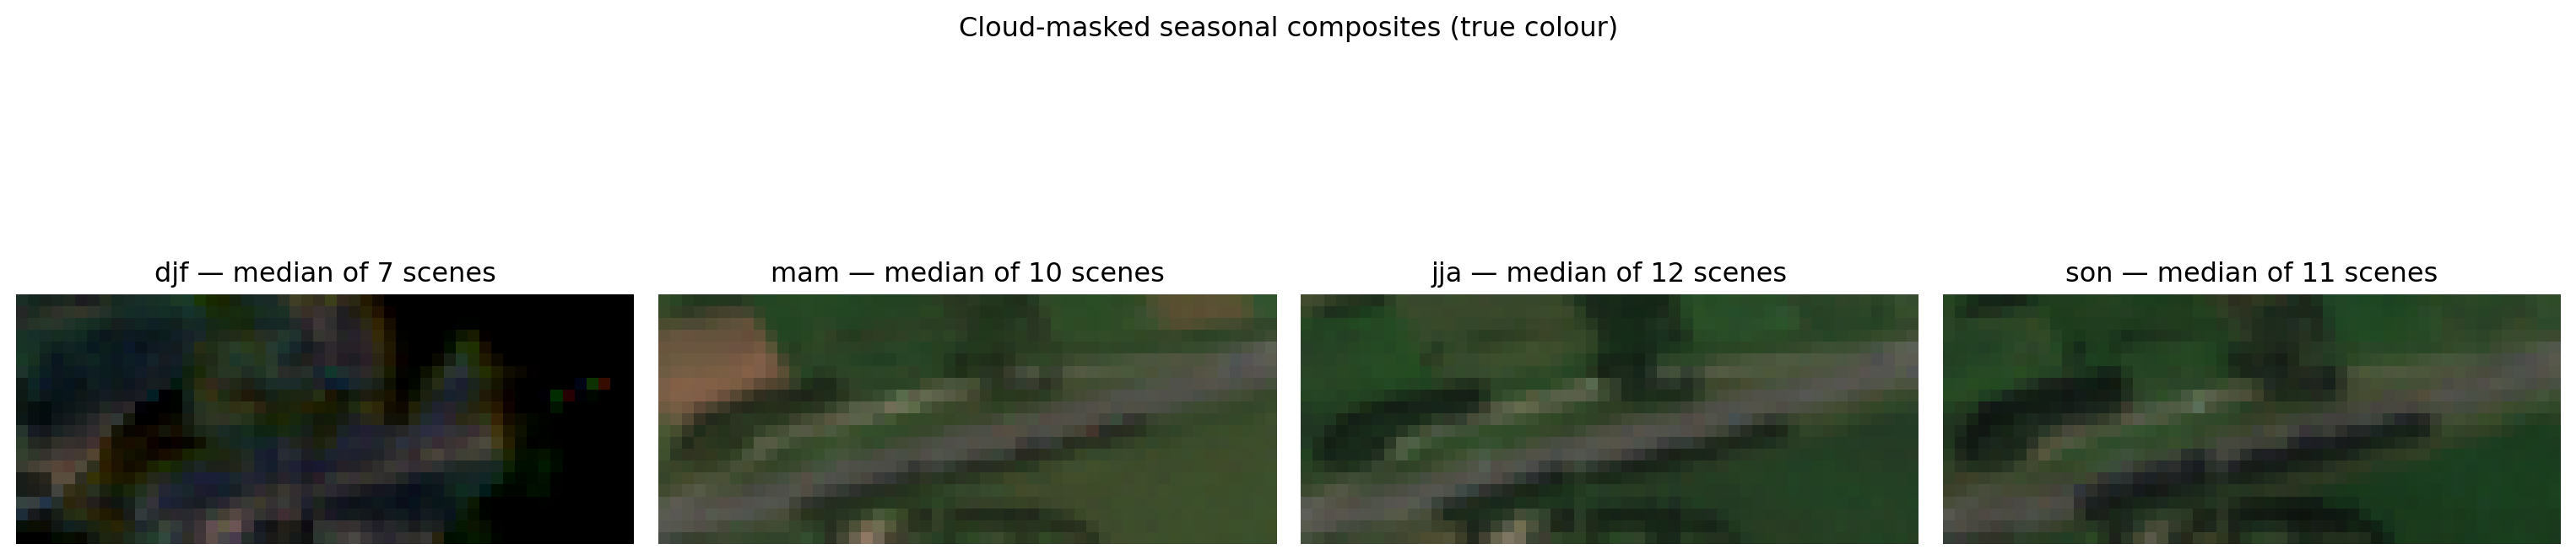

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (season, comp) in zip(axes, composites.items()):
    ax.axis("off")
    if comp is None:
        ax.set_title(f"{season}: no scenes")
        continue
    rgb = np.dstack([comp[b].values for b in ("red", "green", "blue")])
    ax.imshow(np.clip(rgb / 0.25, 0, 1))  # stretch reflectance for display
    ax.set_title(f"{season} — median of {comp.attrs['n_scenes']} scenes")
fig.suptitle("Cloud-masked seasonal composites (true colour)", y=1.02)
plt.tight_layout()

### Step 3 — vegetation: NDVI and its seasonal swing

NDVI = (NIR − red) / (NIR + red): healthy vegetation reflects strongly in near-infrared
and absorbs red, so it scores high. Comparing **summer (jja)** against **winter (djf)**
separates deciduous trees (large drop) from evergreen vegetation and grass. For NDVI the
composites carry extra-masked bands (`red_veg`, `nir_veg`) where cloud *shadow* pixels
are also removed — for shadow detection we deliberately keep those.

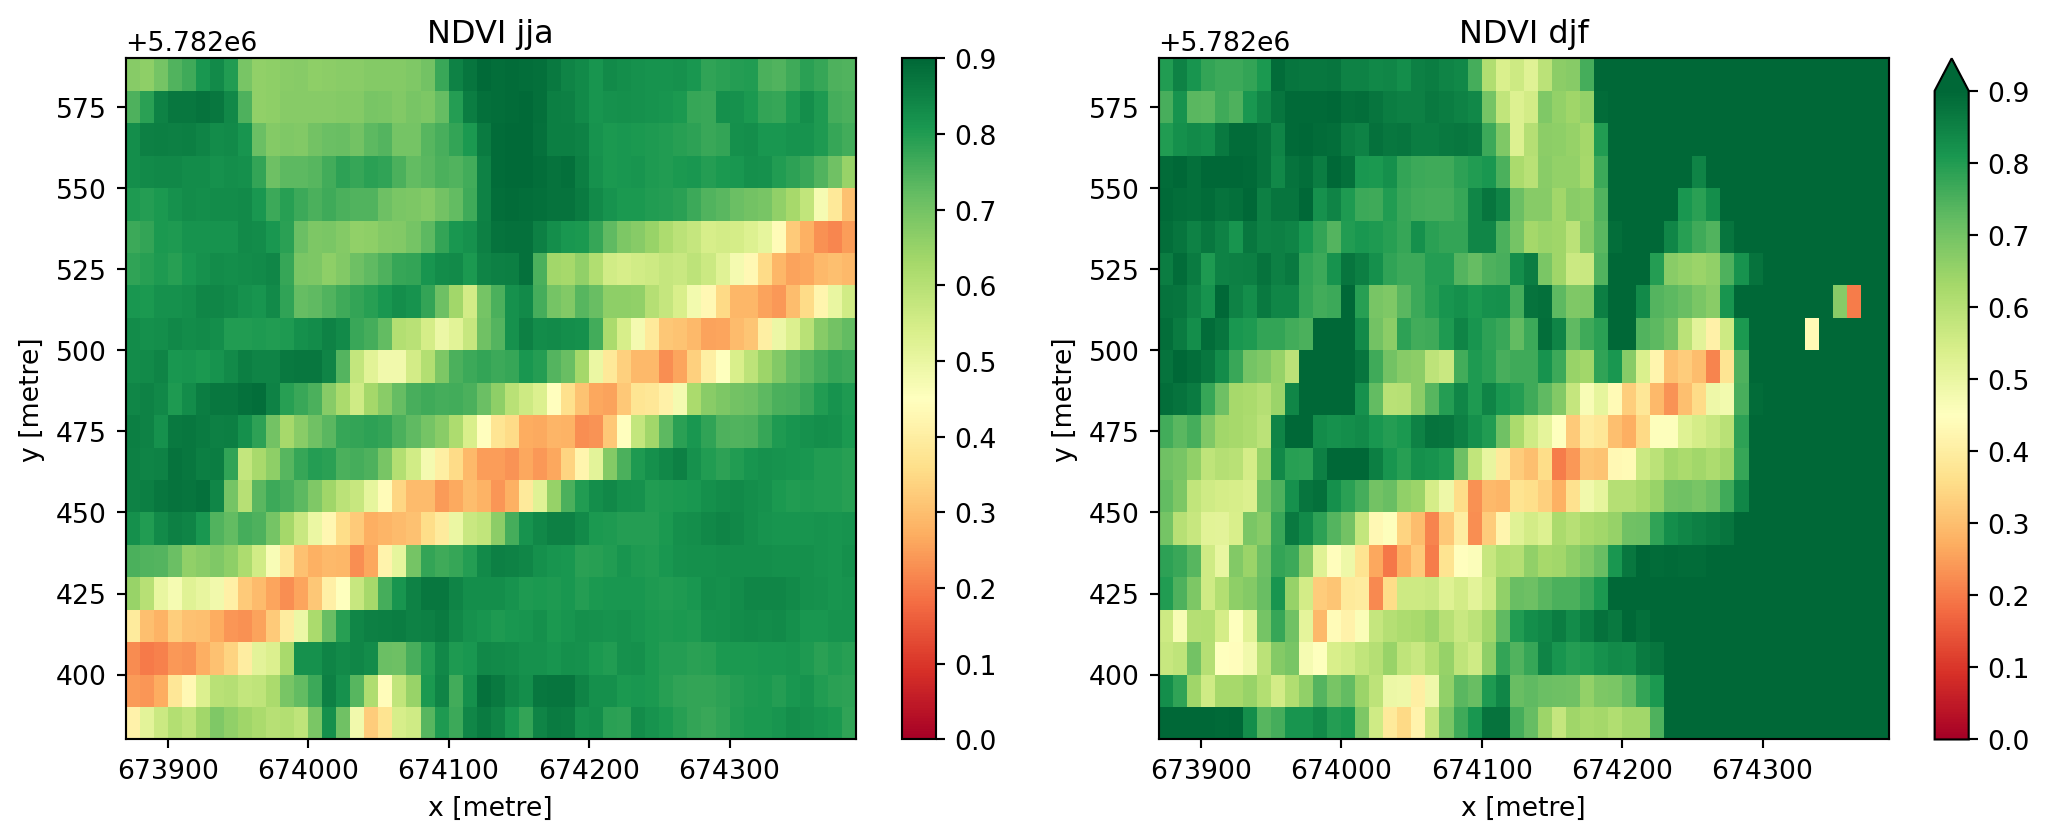

In [9]:
from shaduw_langs_de_snelweg.metrics import ndvi

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, season in zip(axes, ("jja", "djf")):
    ndvi(composites[season]).plot(ax=ax, vmin=0.0, vmax=0.9, cmap="RdYlGn")
    ax.set_title(f"NDVI {season}")
plt.tight_layout()

### Step 4 — detected shadow in the ~10:30 composites

Sentinel-2 passes over the Netherlands around 10:30 local time, so persistent dark
pixels in the composite *are* morning shadow. "Dark" is broadband brightness
(R+G+B+NIR)/4 below a calibrated threshold — NIR must be included, because vegetation is
dark in the visible bands but bright in NIR, while true shadow is dark in all four.

The fraction is evaluated over the **parking polygon only** (that is where the car
stands):

detected shadow fraction (summer, parking only): 0.0


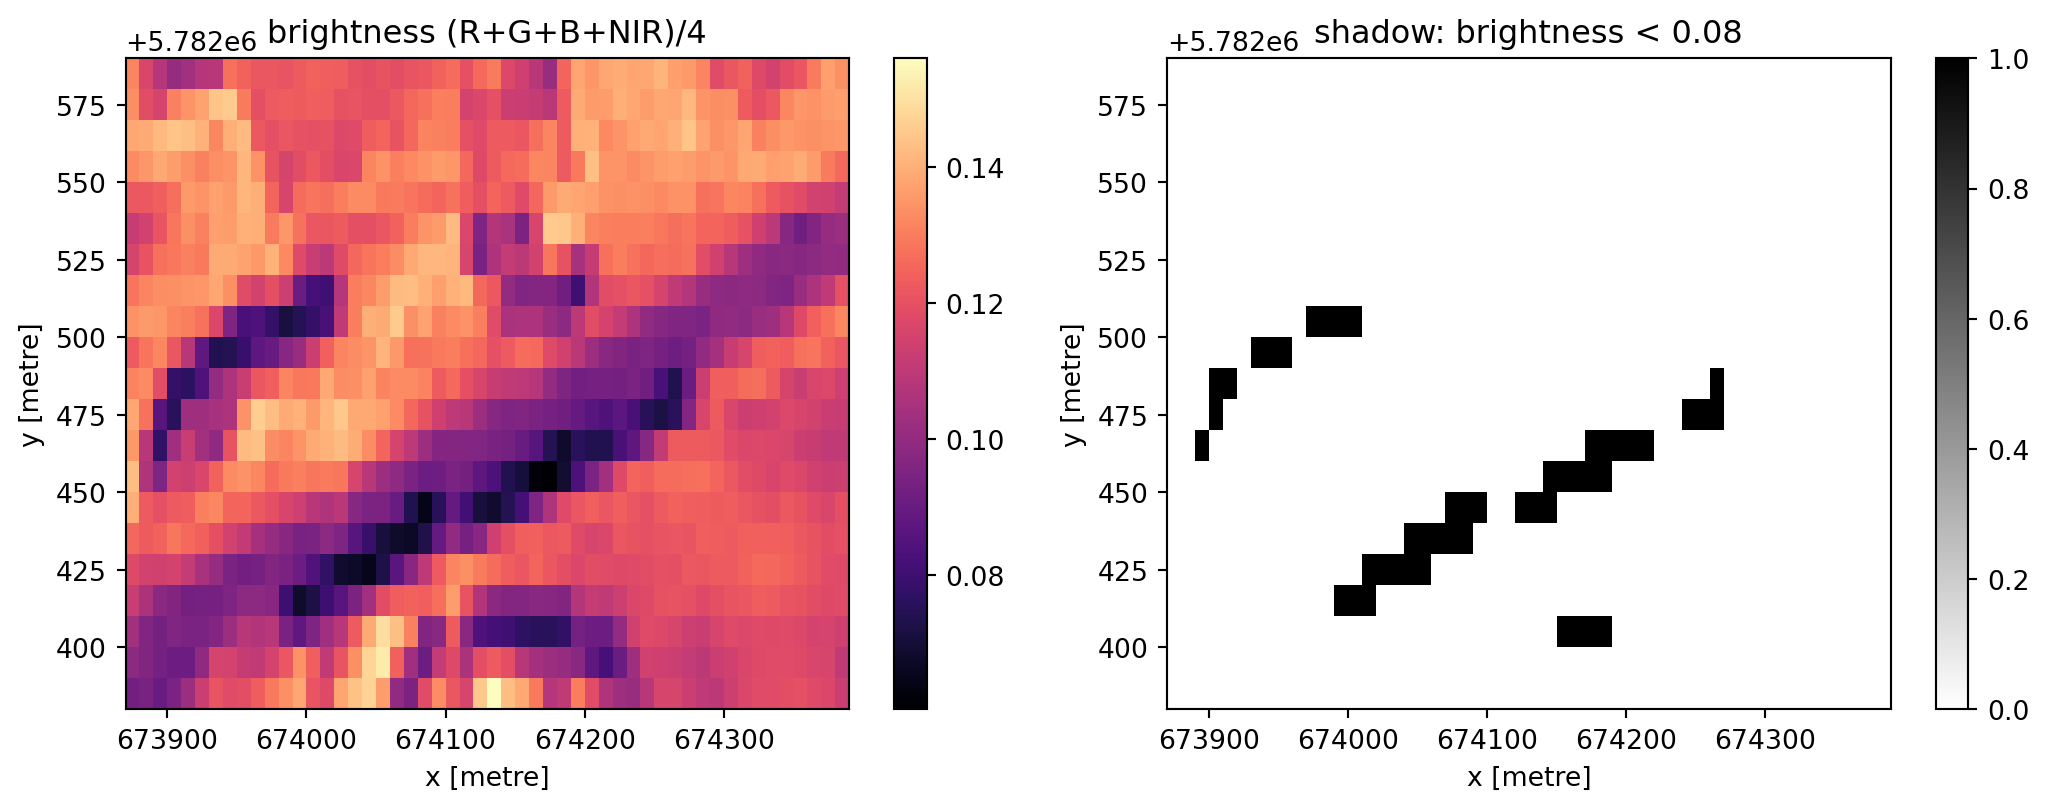

In [10]:
from shaduw_langs_de_snelweg.metrics import (
    brightness,
    detected_shadow_fraction,
    mask_for_geometry,
)

jja = composites["jja"]
bright = brightness(jja)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bright.plot(ax=axes[0], cmap="magma")
axes[0].set_title("brightness (R+G+B+NIR)/4")
(bright < cfg.detection.brightness_threshold).plot(ax=axes[1], cmap="gray_r")
axes[1].set_title(f"shadow: brightness < {cfg.detection.brightness_threshold}")
plt.tight_layout()

parking_mask = mask_for_geometry(jja, stop.geometry)
print(
    "detected shadow fraction (summer, parking only):",
    round(detected_shadow_fraction(jja, parking_mask, cfg.detection), 3),
)

### Step 5 — canopy height and the modelled shadow footprint

The detected shadow only shows 10:30 — but a parked car cares about the *afternoon*.
So we load a 1 m **canopy height model** (Meta/WRI, global, on AWS Open Data; the
clipped window is cached per stop) and run the same ray-marching shadow caster from the
synthetic demo on the real canopy, at the hours and date from the config
(summer solstice, 12 h and 15 h). The sun position comes from `pvlib`.

Text(0.5, 1.0, 'Canopy height (m), 1.0 m grid')

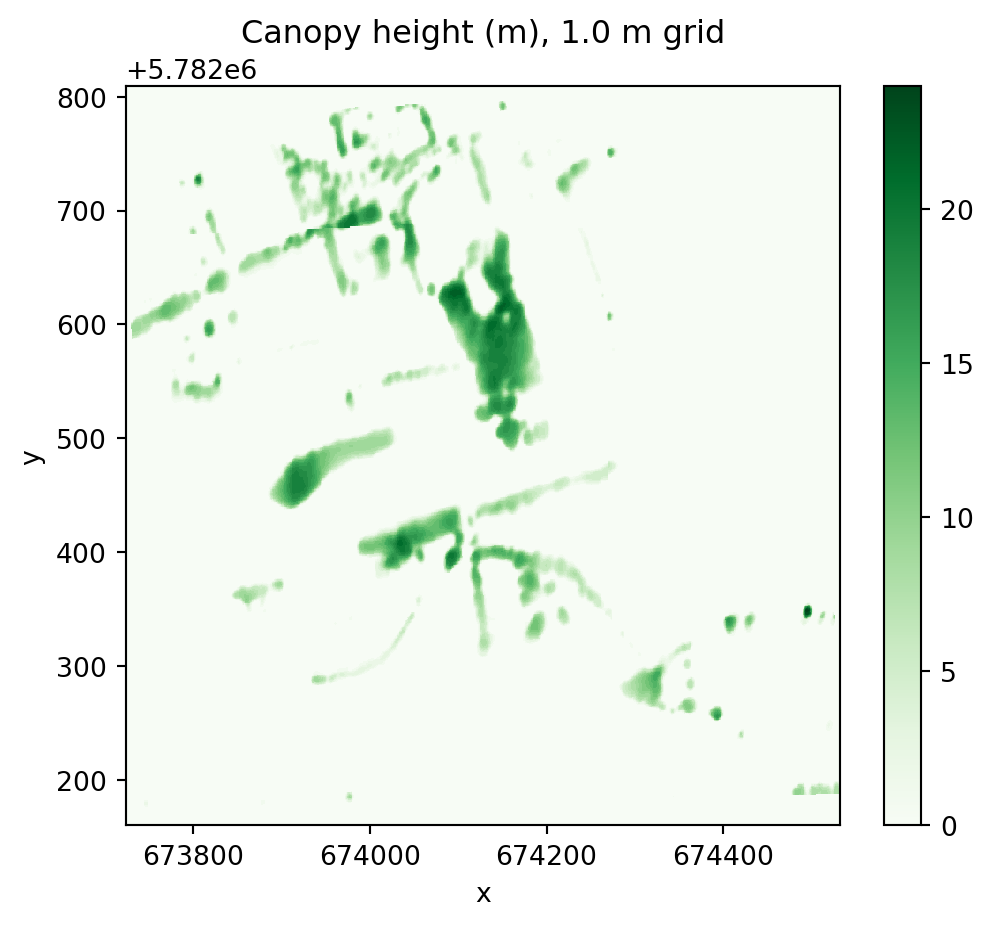

In [11]:
from shaduw_langs_de_snelweg.canopy import load_canopy

chm = load_canopy(stop["aoi"], cfg.canopy, cfg.cache_dir, stop["stop_id"])
chm.plot(cmap="Greens", vmin=0, figsize=(6, 5))
plt.title(f"Canopy height (m), {cfg.canopy.resolution} m grid")

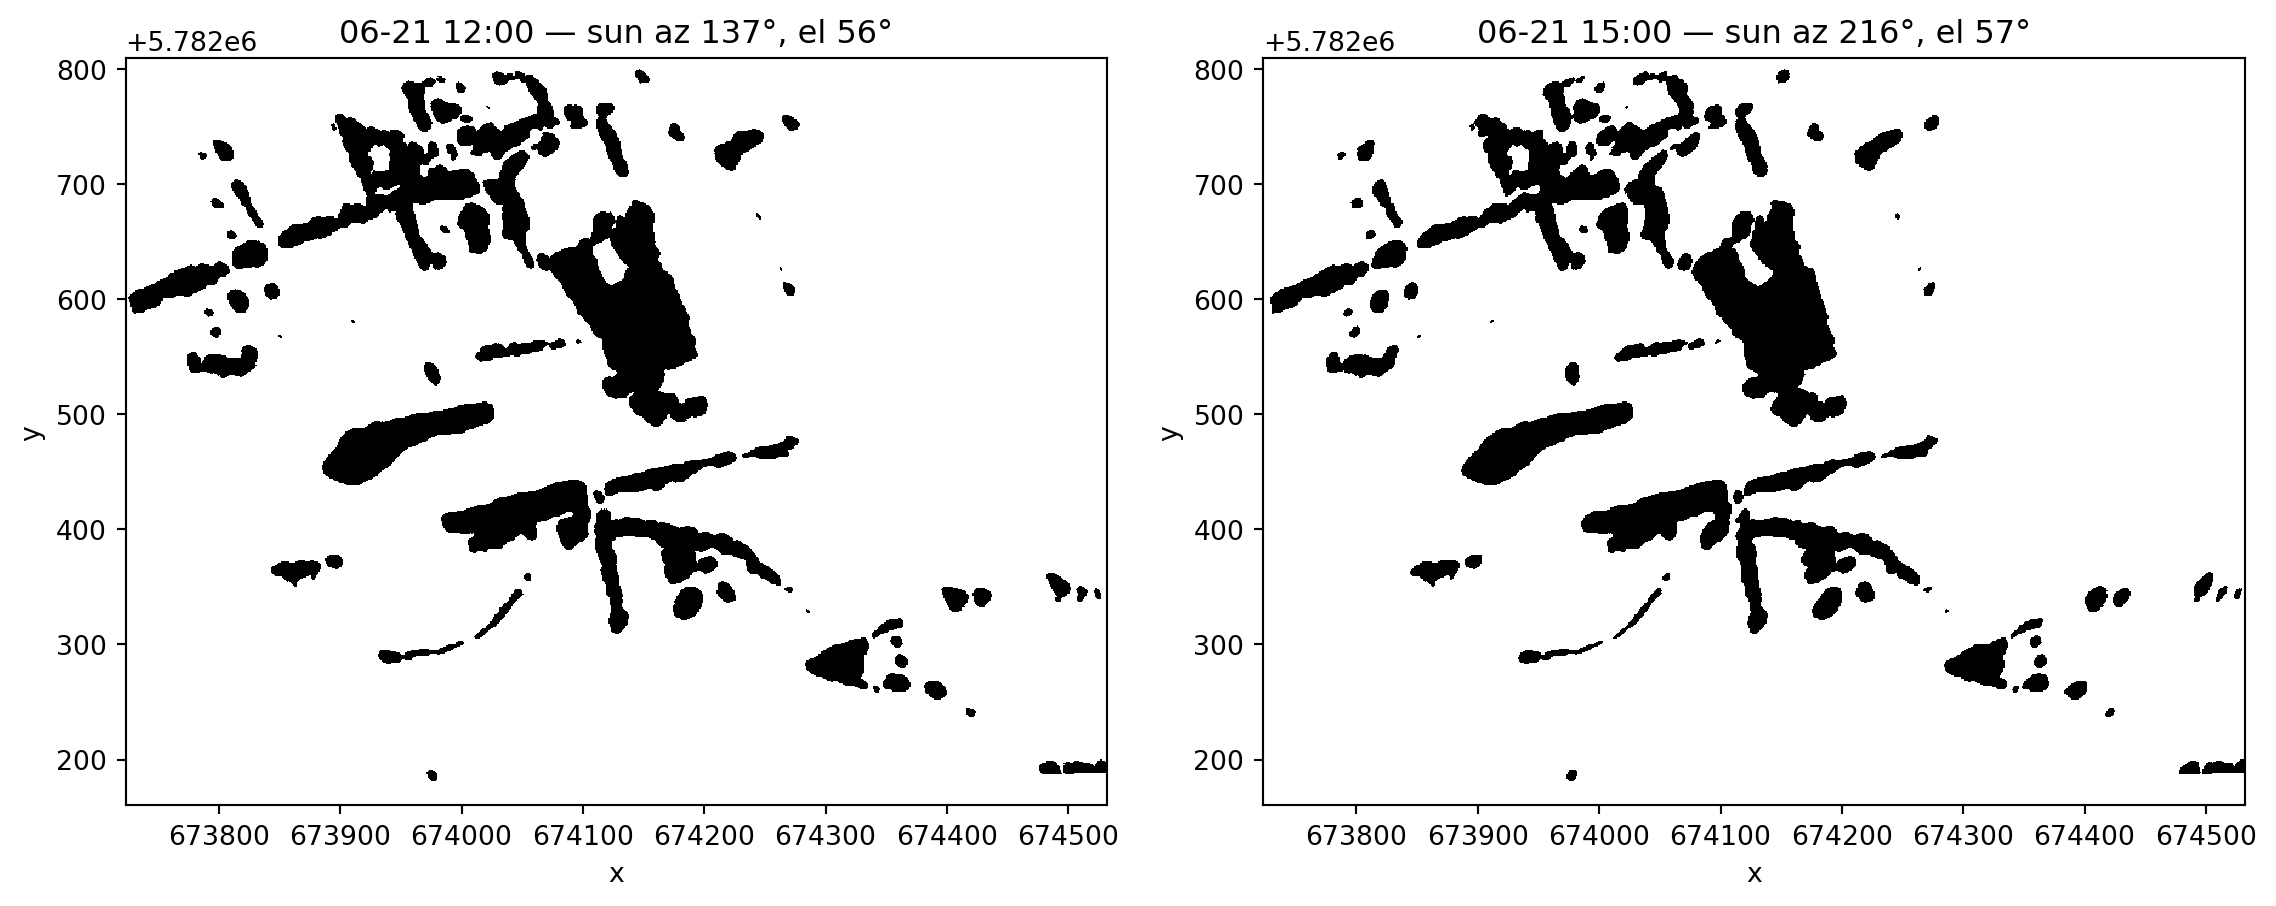

In [12]:
import datetime as dt

from shaduw_langs_de_snelweg.shadow import (
    local_time,
    modeled_shadow_mask,
    solar_position,
)

year = dt.date.today().year
fig, axes = plt.subplots(1, len(cfg.shadow.hours), figsize=(12, 5))
for ax, hour in zip(axes, cfg.shadow.hours):
    when = local_time(cfg.shadow.date, hour, cfg.shadow.timezone, year)
    azimuth, elevation = solar_position(center.y, center.x, when)
    mask = modeled_shadow_mask(
        chm, center.y, center.x, when, cfg.shadow.self_shade_height_m
    )
    mask.plot(ax=ax, cmap="gray_r", add_colorbar=False)
    ax.set_title(
        f"{cfg.shadow.date} {hour}:00 — sun az {azimuth:.0f}°, el {elevation:.0f}°"
    )
plt.tight_layout()

### Step 6 — metrics, score, class

`compute_stop_metrics` bundles all of the above with fixed zonal conventions: NDVI and
tree fraction over the **AOI**, mean canopy height over the **buffer ring**, both shadow
fractions over the **parking polygon**.

The composite score is a weighted mean — modelled 15 h shadow (0.5), tree fraction
(0.3), detected summer shadow (0.2) — renormalised over whatever is available, so one
missing input degrades the score gracefully instead of dragging it to zero. Class
bounds: below 0.15 → `none`, above 0.40 → `good`, in between → `partial`.

In [13]:
import pandas as pd

from shaduw_langs_de_snelweg.metrics import compute_stop_metrics
from shaduw_langs_de_snelweg.score import shade_class, shade_score

metrics = compute_stop_metrics(
    parking_geom_4326=stop.geometry,
    aoi_geom_4326=stop["aoi"],
    composites=composites,
    chm=chm,
    detection_cfg=cfg.detection,
    shadow_cfg=cfg.shadow,
    tree_threshold=cfg.canopy.tree_height_threshold_m,
)
metrics["shade_score"] = shade_score(metrics, cfg.score)
metrics["shade_class"] = shade_class(metrics["shade_score"], cfg.score)
pd.Series(metrics).round(3)

ndvi_summer                  0.62146
ndvi_winter                 0.726294
ndvi_delta                 -0.104834
tree_fraction               0.151751
mean_canopy_height          1.748198
shadow_frac_detected_djf    0.740741
shadow_frac_detected_mam         0.0
shadow_frac_detected_jja         0.0
shadow_frac_detected_son    0.031746
n_scenes_used                     40
shadow_frac_modeled_12h     0.190469
shadow_frac_modeled_15h     0.190736
shade_score                 0.140893
shade_class                     none
dtype: object

In [14]:
# The score, written out by hand — same number as shade_score() above:
s = cfg.score
manual = (
    s.w_modeled_15h * metrics["shadow_frac_modeled_15h"]
    + s.w_tree_fraction * metrics["tree_fraction"]
    + s.w_detected_summer * metrics["shadow_frac_detected_jja"]
)
print(
    f"manual: {manual:.4f}   shade_score(): {metrics['shade_score']:.4f}"
    f"   class: {metrics['shade_class']}"
)

manual: 0.1409   shade_score(): 0.1409   class: none


### Step 7 — the product

In a batch run every stop becomes one row in a GeoDataFrame, written as **GeoParquet**
(analysis), **GeoPackage** (GIS) and an interactive **web map** where each stop is
coloured by its shade class. This is our single stop rendered exactly like the final
map:

In [15]:
from shaduw_langs_de_snelweg.outputs import CLASS_COLORS

color = CLASS_COLORS[metrics["shade_class"]]
m = folium.Map(location=[center.y, center.x], zoom_start=16)
folium.GeoJson(
    stop.geometry.__geo_interface__,
    style_function=lambda f, c=color: {"color": c, "fillColor": c, "fillOpacity": 0.35},
).add_to(m)
folium.CircleMarker(
    location=[center.y, center.x],
    radius=7,
    color=color,
    fill=True,
    fill_opacity=0.9,
    popup=folium.Popup(
        f"<b>{stop['name']}</b><br>"
        f"shade_score: {metrics['shade_score']:.3f}<br>"
        f"shade_class: {metrics['shade_class']}<br>"
        f"modelled 15h shadow: {metrics['shadow_frac_modeled_15h']:.3f}<br>"
        f"tree fraction: {metrics['tree_fraction']:.3f}",
        max_width=300,
    ),
).add_to(m)
m

### Running it at scale

The batch pipeline is the same code in a loop, with two layers of on-disk caching (the
prepared stop table and one JSON per finished stop), so interrupted runs resume where
they left off and failed stops are retried on the next run:

```bash
pixi run run        # 5 prototype stops
pixi run discover   # find all ~545 NL rest/service areas in OSM
pixi run run-full   # process all of them (8 parallel workers)
```